In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf

# ---- Ngarko modelin e ruajtur ----
model = tf.keras.models.load_model('CNN_model.keras')
print("✅ Model loaded successfully!")

# ---- Classification report (validation set) ----
val_pred = model.predict(x_val, verbose=0)
val_pred_classes = np.argmax(val_pred, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

print("MLP Classification Report (validation):")
print(classification_report(y_val_classes, val_pred_classes, target_names=train_ds.class_names))

# ---- Confusion matrix (validation set) ----
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val_classes, val_pred_classes, 
                                        display_labels=train_ds.class_names,
                                        ax=ax, cmap="Blues")
plt.title("MLP Confusion Matrix (validation)")
plt.show()

✅ Model loaded successfully!


NameError: name 'x_val' is not defined

Found 149 files belonging to 3 classes.
✅ Klasat e gjetura: ['paper', 'rock', 'scissors']
🚀 Duke testuar modelin në 150 imazhe të reja...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


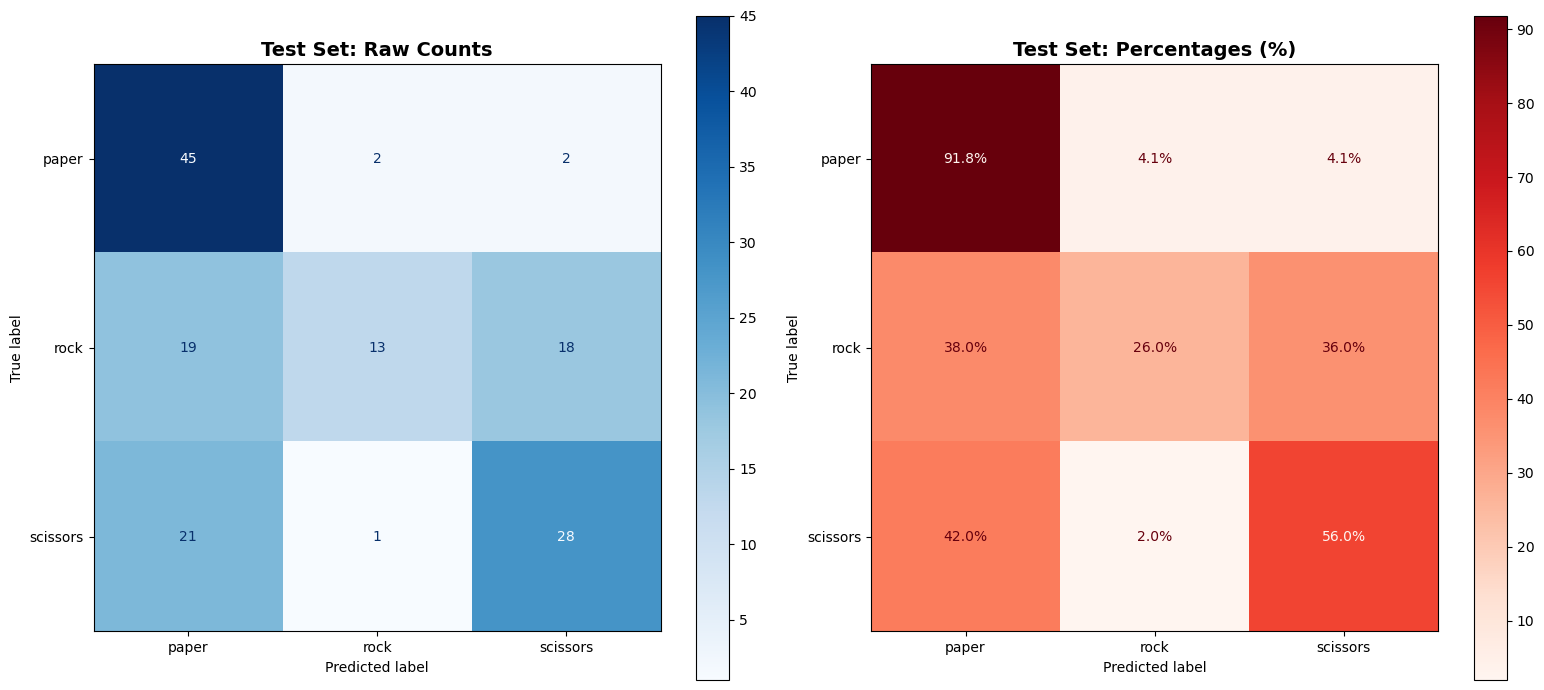


 📋 TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

       paper       0.53      0.92      0.67        49
        rock       0.81      0.26      0.39        50
    scissors       0.58      0.56      0.57        50

    accuracy                           0.58       149
   macro avg       0.64      0.58      0.55       149
weighted avg       0.64      0.58      0.54       149



In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. KONFIGURIMI DHE NGARKIMI I TEST SET
# ==========================================
test_path = r"C:\Users\User\Downloads\MLP_Projects\3G_Test\ROCK_PAPER_SCISSOR\test" # Update këtë path
img_size = (128, 128)
batch_size = 32

# Ngarkojmë imazhet nga dosja test
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False  # SHUMË E RËNDËSISHME: False që parashikimet të përputhen me etiketat
)

# Marrja e emrave të klasave (Rock, Paper, Scissors)
class_names = test_ds.class_names
print(f"✅ Klasat e gjetura: {class_names}")

# Normalizimi (duhet të jetë identik me trajnimin: 1/255)
normalization = layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

# ==========================================
# 2. NGARKIMI I MODELIT DHE PARASHIKIMET
# ==========================================
model = tf.keras.models.load_model('CNN_model8.keras')
print("🚀 Duke testuar modelin në 150 imazhe të reja...")

# Merr parashikimet
predictions = model.predict(test_ds, verbose=1)
pred_classes = np.argmax(predictions, axis=1)

# Merr etiketat e vërteta nga dataseti
y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# ==========================================
# 3. VIZUALIZIMI ME PËRQINDJE (%)
# ==========================================
cm = confusion_matrix(y_true, pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Shifrat (Counts)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Test Set: Raw Counts', fontsize=14, fontweight='bold')

# Plot 2: Përqindjet (%)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp2.plot(cmap='Reds', ax=axes[1], values_format='.1f')
axes[1].set_title('Test Set: Percentages (%)', fontsize=14, fontweight='bold')

# Shto % simbolin te kutitë
for text in disp2.text_.ravel():
    text.set_text(text.get_text() + '%')

plt.tight_layout()
plt.show()

# ==========================================
# 4. RAPORTI FINAL
# ==========================================
print("\n" + "="*60)
print(" 📋 TEST SET CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, pred_classes, target_names=class_names))

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("_model.keras")
print("✅ Model loaded")


# Ngarko test dataset-in

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "ROCK_PAPER_SCISSOR/test",
    image_size=(128, 128),   # përdor të njëjtën madhësi si në train
    batch_size=32,
    shuffle=False            # mos e përziej, që të krahasosh lehtë
)


Found 25 files belonging to 3 classes.


# Merr imazhet dhe etiketat

In [3]:
import numpy as np
test_images, test_labels = [], []
for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)



NameError: name 'test_ds' is not defined

# Predikime dhe raport

In [2]:
predictions = model.predict(test_images, verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = test_labels

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
class_names = test_ds.class_names

print(classification_report(true_classes, pred_classes, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(true_classes, pred_classes,
                                        display_labels=class_names,
                                        cmap="Blues")
plt.show()


NameError: name 'test_images' is not defined

✅ Model loaded
Found 149 files belonging to 3 classes.

Classification Report (Test Set):
              precision    recall  f1-score   support

       paper       1.00      0.02      0.04        49
        rock       0.34      1.00      0.51        50
    scissors       0.00      0.00      0.00        50

    accuracy                           0.34       149
   macro avg       0.45      0.34      0.18       149
weighted avg       0.44      0.34      0.18       149



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


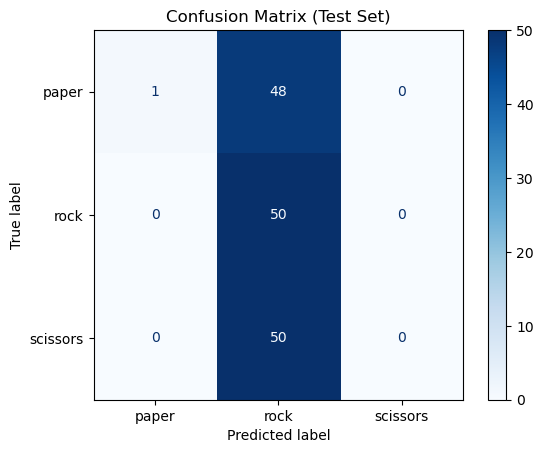

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Ngarko modelin e ruajtur
model = tf.keras.models.load_model("best_model1.keras")
print("✅ Model loaded")

# 2. Ngarko test dataset-in
test_ds = tf.keras.utils.image_dataset_from_directory(
    "ROCK_PAPER_SCISSOR/test",
    image_size=(128, 128),
    batch_size=32,
    shuffle=False,
    label_mode="int"   # etiketat si integer
)

# 3. Merr imazhet dhe etiketat
test_images, test_labels = [], []
for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images).astype("float32") / 255.0
test_labels = np.concatenate(test_labels)

# 4. Predikime
predictions = model.predict(test_images, verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = test_labels  # tashmë janë integer

# 5. Raporti i klasifikimit
class_names = test_ds.class_names
print("\nClassification Report (Test Set):")
print(classification_report(true_classes, pred_classes, target_names=class_names))

# 6. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(true_classes, pred_classes,
                                        display_labels=class_names,
                                        cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()


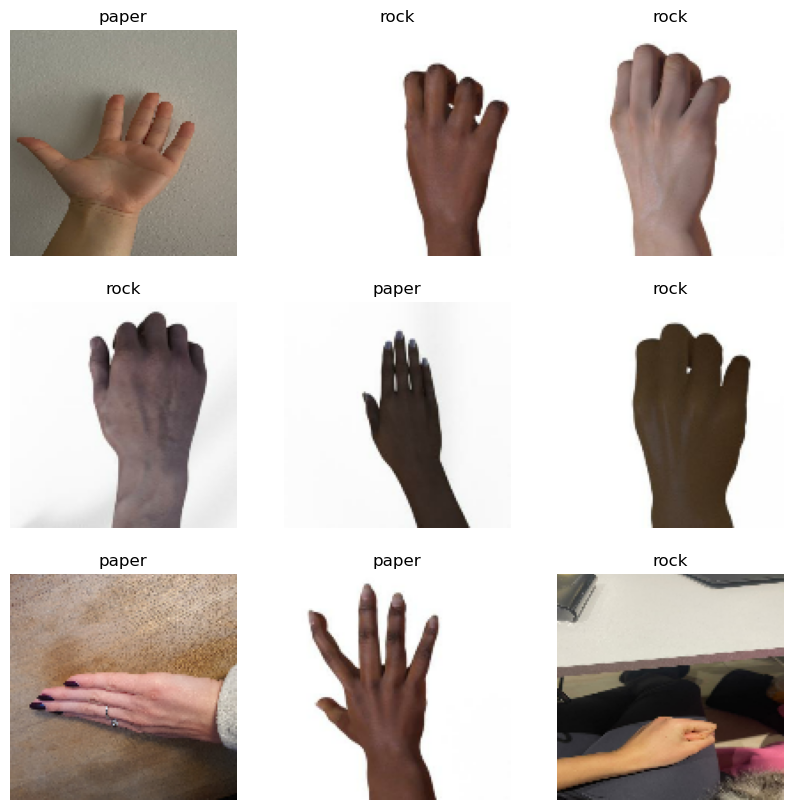

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Merr të gjitha imazhet
all_images, all_labels = [], []
for images, labels in test_ds:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)

# Zgjidh 9 indekse rastësore
rand_idx = np.random.choice(len(all_images), size=9, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(rand_idx):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(all_images[idx].astype("uint8"))
    plt.title(test_ds.class_names[all_labels[idx]])
    plt.axis("off")
plt.show()


In [10]:
def plot_random_predictions(model, dataset, class_names):
    images, labels = next(iter(dataset))
    preds = model.predict(images)
    
    plt.figure(figsize=(12, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        
        actual_idx = np.argmax(labels[i])
        pred_idx = np.argmax(preds[i])
        confidence = 100 * np.max(preds[i])
        
        color = 'green' if actual_idx == pred_idx else 'red'
        
        plt.title(f"Actual: {class_names[actual_idx]}\nPred: {class_names[pred_idx]} ({confidence:.1f}%)", 
                  color=color, fontsize=10)
        plt.axis("off")
    plt.tight_layout()

In [1]:
# KY ËSHTË PROBLEM!
print("="*60)
print("TEST DATASET CLASS ORDER:")
print(f"Class names from test folders: {test_ds.class_names}")
print(f"Index 0: {test_ds.class_names[0]}")
print(f"Index 1: {test_ds.class_names[1]}")
print(f"Index 2: {test_ds.class_names[2]}")
print("="*60)

TEST DATASET CLASS ORDER:


NameError: name 'test_ds' is not defined